
## Backtracking, Branch & Bound, and Grey Wolf Optimizer


In [3]:
import time
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from typing import List, Tuple, Dict, Any
import json

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
print('✓ Libraries imported')

✓ Libraries imported


## Part 1: Algorithm Implementation

### Base Solver Class

In [4]:
class KnapsackSolver(ABC):
    """Abstract base class for Knapsack solvers"""
    
    def __init__(self, capacity: int, items: List[Tuple[int, int]]):
        self.capacity = capacity
        self.items = items
        self.n = len(items)
        self.result = None
        self.execution_time = 0
        self.best_value = 0
        self.convergence_history = []
    
    @abstractmethod
    def solve(self) -> Dict[str, Any]:
        pass
    
    def calculate_fitness(self, solution: List[int]) -> Tuple[int, int]:
        total_weight = sum(solution[i] * self.items[i][0] for i in range(self.n))
        total_value = sum(solution[i] * self.items[i][1] for i in range(self.n))
        return total_weight, total_value
    
    def is_feasible(self, solution: List[int]) -> bool:
        weight, _ = self.calculate_fitness(solution)
        return weight <= self.capacity

print('✓ Base class created')

✓ Base class created


### Backtracking Algorithm

In [5]:
class BacktrackingSolver(KnapsackSolver):
    def solve(self) -> Dict[str, Any]:
        start_time = time.time()
        best_value = [0]
        best_solution = [[0] * self.n]
        self.convergence_history = [0]
        
        def backtrack(idx, current_weight, current_value, solution):
            if current_value > best_value[0]:
                best_value[0] = current_value
                best_solution[0] = solution[:]
                self.convergence_history.append(best_value[0])
            
            if idx == self.n:
                return
            
            if current_weight + self.items[idx][0] <= self.capacity:
                solution[idx] = 1
                backtrack(idx + 1, current_weight + self.items[idx][0],
                         current_value + self.items[idx][1], solution)
                solution[idx] = 0
            
            backtrack(idx + 1, current_weight, current_value, solution)
        
        backtrack(0, 0, 0, [0] * self.n)
        self.execution_time = time.time() - start_time
        self.best_value = best_value[0]
        
        return {
            'best_value': best_value[0],
            'best_solution': best_solution[0],
            'execution_time': self.execution_time,
            'convergence_history': self.convergence_history
        }

print('✓ Backtracking solver created')

✓ Backtracking solver created


### Branch & Bound Algorithm

In [6]:
class BranchAndBoundSolver(KnapsackSolver):
    """Branch & Bound with upper bound pruning using fractional knapsack relaxation"""
    def solve(self) -> Dict[str, Any]:
        start_time = time.time()
        
        # Sort by value/weight ratio for better pruning order
        self.sorted_indices = sorted(range(self.n), 
                                    key=lambda i: self.items[i][1] / self.items[i][0],
                                    reverse=True)
        
        best_value = [0]
        best_solution = [[0] * self.n]
        self.convergence_history = [0]
        nodes_pruned = [0]
        
        def upper_bound(idx, remaining_capacity):
            """Calculate upper bound using fractional knapsack relaxation"""
            bound = 0
            capacity = remaining_capacity
            
            for i in range(idx, self.n):
                real_idx = self.sorted_indices[i]
                if self.items[real_idx][0] <= capacity:
                    bound += self.items[real_idx][1]
                    capacity -= self.items[real_idx][0]
                else:
                    # Take fraction of next item
                    bound += (capacity / self.items[real_idx][0]) * self.items[real_idx][1]
                    break
            return bound
        
        def backtrack(idx, current_weight, current_value, solution):
            # KEY DIFFERENCE FROM BACKTRACKING: Pruning using upper bound
            ub_value = current_value + upper_bound(idx, self.capacity - current_weight)
            if ub_value <= best_value[0]:
                nodes_pruned[0] += 1
                return  # Prune this branch
            
            if current_value > best_value[0]:
                best_value[0] = current_value
                best_solution[0] = solution[:]
                self.convergence_history.append(best_value[0])
            
            if idx == self.n:
                return
            
            real_idx = self.sorted_indices[idx]
            if current_weight + self.items[real_idx][0] <= self.capacity:
                solution[real_idx] = 1
                backtrack(idx + 1, current_weight + self.items[real_idx][0],
                         current_value + self.items[real_idx][1], solution)
                solution[real_idx] = 0
            
            backtrack(idx + 1, current_weight, current_value, solution)
        
        backtrack(0, 0, 0, [0] * self.n)
        self.execution_time = time.time() - start_time
        self.best_value = best_value[0]
        
        return {
            'best_value': best_value[0],
            'best_solution': best_solution[0],
            'execution_time': self.execution_time,
            'convergence_history': self.convergence_history,
            'nodes_pruned': nodes_pruned[0]
        }

print('✓ Branch & Bound solver created')

✓ Branch & Bound solver created


### Grey Wolf Optimizer

In [7]:
class GWOSolver(KnapsackSolver):
    def __init__(self, capacity: int, items: List[Tuple[int, int]], population_size: int = 30, iterations: int = 100):
        super().__init__(capacity, items)
        self.population_size = population_size
        self.iterations = iterations
    
    def solve(self) -> Dict[str, Any]:
        start_time = time.time()
        population = self._init_population()
        fitness_values = [self._evaluate_fitness(wolf) for wolf in population]
        
        sorted_indices = sorted(range(self.population_size), key=lambda i: fitness_values[i], reverse=True)
        alpha_idx, beta_idx, delta_idx = sorted_indices[0], sorted_indices[1], sorted_indices[2]
        
        alpha_wolf = population[alpha_idx]
        beta_wolf = population[beta_idx]
        delta_wolf = population[delta_idx]
        
        best_value = fitness_values[alpha_idx]
        self.convergence_history = [best_value]
        
        for iteration in range(self.iterations):
            a = 2 - 2 * (iteration / self.iterations)
            
            for i in range(self.population_size):
                new_wolf = [0] * self.n
                
                for j in range(self.n):
                    c1 = 2 * random.random() - 1
                    c2 = 2 * random.random() - 1
                    c3 = 2 * random.random() - 1
                    
                    a1 = a * (2 * random.random() - 1)
                    a2 = a * (2 * random.random() - 1)
                    a3 = a * (2 * random.random() - 1)
                    
                    d_alpha = abs(c1 * alpha_wolf[j] - population[i][j])
                    x1 = alpha_wolf[j] - a1 * d_alpha
                    
                    d_beta = abs(c2 * beta_wolf[j] - population[i][j])
                    x2 = beta_wolf[j] - a2 * d_beta
                    
                    d_delta = abs(c3 * delta_wolf[j] - population[i][j])
                    x3 = delta_wolf[j] - a3 * d_delta
                    
                    x_avg = (x1 + x2 + x3) / 3.0
                    new_wolf[j] = 1 if random.random() < self._sigmoid(x_avg) else 0
                
                new_wolf = self._repair_solution(new_wolf)
                new_fitness = self._evaluate_fitness(new_wolf)
                
                if new_fitness > fitness_values[i]:
                    population[i] = new_wolf
                    fitness_values[i] = new_fitness
            
            sorted_indices = sorted(range(self.population_size), key=lambda i: fitness_values[i], reverse=True)
            alpha_idx, beta_idx, delta_idx = sorted_indices[0], sorted_indices[1], sorted_indices[2]
            
            alpha_wolf = population[alpha_idx]
            beta_wolf = population[beta_idx]
            delta_wolf = population[delta_idx]
            
            current_best = fitness_values[alpha_idx]
            if current_best > best_value:
                best_value = current_best
            
            self.convergence_history.append(best_value)
        
        best_idx = fitness_values.index(max(fitness_values))
        best_solution = population[best_idx]
        
        self.execution_time = time.time() - start_time
        self.best_value = best_value
        
        return {
            'best_value': best_value,
            'best_solution': best_solution,
            'execution_time': self.execution_time,
            'convergence_history': self.convergence_history
        }
    
    def _init_population(self):
        population = []
        for _ in range(self.population_size):
            wolf = [random.randint(0, 1) for _ in range(self.n)]
            wolf = self._repair_solution(wolf)
            population.append(wolf)
        return population
    
    def _sigmoid(self, x):
        try:
            return 1 / (1 + math.exp(-x))
        except:
            return 0.5
    
    def _evaluate_fitness(self, solution):
        weight, value = self.calculate_fitness(solution)
        if weight > self.capacity:
            penalty = (weight - self.capacity) * 10
            return max(0, value - penalty)
        return value
    
    def _repair_solution(self, solution):
        weight, value = self.calculate_fitness(solution)
        if weight <= self.capacity:
            return solution
        
        items_in_solution = [(i, self.items[i][1] / self.items[i][0]) for i in range(self.n) if solution[i] == 1]
        items_in_solution.sort(key=lambda x: x[1])
        
        repaired = solution[:]
        for item_idx, _ in items_in_solution:
            if weight <= self.capacity:
                break
            repaired[item_idx] = 0
            weight -= self.items[item_idx][0]
        
        return repaired

print('✓ GWO solver created')

✓ GWO solver created


## Part 2: Data Generation & Benchmarking

In [15]:
class DataGenerator:
    @staticmethod
    def generate_dataset(num_items: int, seed: int = None) -> Tuple[int, List[Tuple[int, int]]]:
        if seed is not None:
            random.seed(seed)
        items = []
        total_weight = 0
        for _ in range(num_items):
            weight = random.randint(1, 50)
            value = random.randint(1, 100)
            items.append((weight, value))
            total_weight += weight
        capacity = int(total_weight * 0.6)
        return capacity, items

print('✓ DataGenerator created')

✓ DataGenerator created


PART 3


In [ ]:
print('📊 GENERATING TEST DATASETS...\n')
results = []

# Test Small Dataset (10 items)
dataset_name = 'Small (10 items)'
capacity, items = DataGenerator.generate_dataset(10, seed=42)
print(f'🔍 Testing {dataset_name}...')
algorithms = [
    ('Backtracking', BacktrackingSolver(capacity, items)),
    ('Branch & Bound', BranchAndBoundSolver(capacity, items)),
    ('GWO', GWOSolver(capacity, items, 30, 100))
]
for algo_name, solver in algorithms:
    result = solver.solve()
    print(f'  ✓ {algo_name:15s} Value={result["best_value"]:6.0f}, Time={result["execution_time"]:8.4f}s')
    results.append({
        'Dataset': dataset_name,
        'Algorithm': algo_name,
        'Items': 10,
        'Best Value': result['best_value'],
        'Time (s)': result['execution_time'],
        'History': result['convergence_history']
    })

# Test Medium Dataset (30 items)
dataset_name = 'Medium (30 items)'
capacity, items = DataGenerator.generate_dataset(30, seed=123)
print(f'\n🔍 Testing {dataset_name}...')
algorithms = [
    ('Branch & Bound', BranchAndBoundSolver(capacity, items)),
    ('GWO', GWOSolver(capacity, items, 30, 100))
]
for algo_name, solver in algorithms:
    result = solver.solve()
    print(f'  ✓ {algo_name:15s} Value={result["best_value"]:6.0f}, Time={result["execution_time"]:8.4f}s')
    results.append({
        'Dataset': dataset_name,
        'Algorithm': algo_name,
        'Items': 30,
        'Best Value': result['best_value'],
        'Time (s)': result['execution_time'],
        'History': result['convergence_history']
    })

# Test Large Dataset (100 items)
dataset_name = 'Large (100 items)'
capacity, items = DataGenerator.generate_dataset(100, seed=456)
print(f'\n🔍 Testing {dataset_name}...')
algorithms = [
    ('GWO', GWOSolver(capacity, items, 50, 150))
]
for algo_name, solver in algorithms:
    result = solver.solve()
    print(f'  ✓ {algo_name:15s} Value={result["best_value"]:6.0f}, Time={result["execution_time"]:8.4f}s')
    results.append({
        'Dataset': dataset_name,
        'Algorithm': algo_name,
        'Items': 100,
        'Best Value': result['best_value'],
        'Time (s)': result['execution_time'],
        'History': result['convergence_history']
    })

# Create DataFrame
df = pd.DataFrame(results)
print('\n✓ Benchmarking complete!')

📊 GENERATING TEST DATASETS...

🔍 Testing Small (10 items)...
  ✓ Backtracking    Value=   327, Time=  0.0000s
  ✓ Branch & Bound  Value=   327, Time=  0.0000s
  ✓ GWO             Value=   327, Time=  0.0760s

🔍 Testing Medium (30 items)...
  ✓ Branch & Bound  Value=  1213, Time=  0.0000s
  ✓ GWO             Value=  1202, Time=  0.2230s

🔍 Testing Large (100 items)...
  ✓ GWO             Value=  4262, Time=  1.8150s


## Part 4: Results Summary

In [10]:
display_df = df[['Dataset', 'Algorithm', 'Items', 'Best Value', 'Time (s)']].copy()
display_df['Time (s)'] = display_df['Time (s)'].apply(lambda x: f'{x:.6f}')
print('\n' + '='*70)
print('BENCHMARK RESULTS')
print('='*70)
print(display_df.to_string(index=False))
print('='*70)


BENCHMARK RESULTS
          Dataset      Algorithm  Items  Best Value Time (s)
 Small (10 items)   Backtracking     10         327 0.001001
 Small (10 items) Branch & Bound     10         327 0.000000
 Small (10 items)            GWO     10         327 0.073999
Medium (30 items) Branch & Bound     30        1213 0.000000
Medium (30 items)            GWO     30        1202 0.209997
Large (100 items)            GWO    100        4262 1.792979


## Part 5: Visualization - Convergence

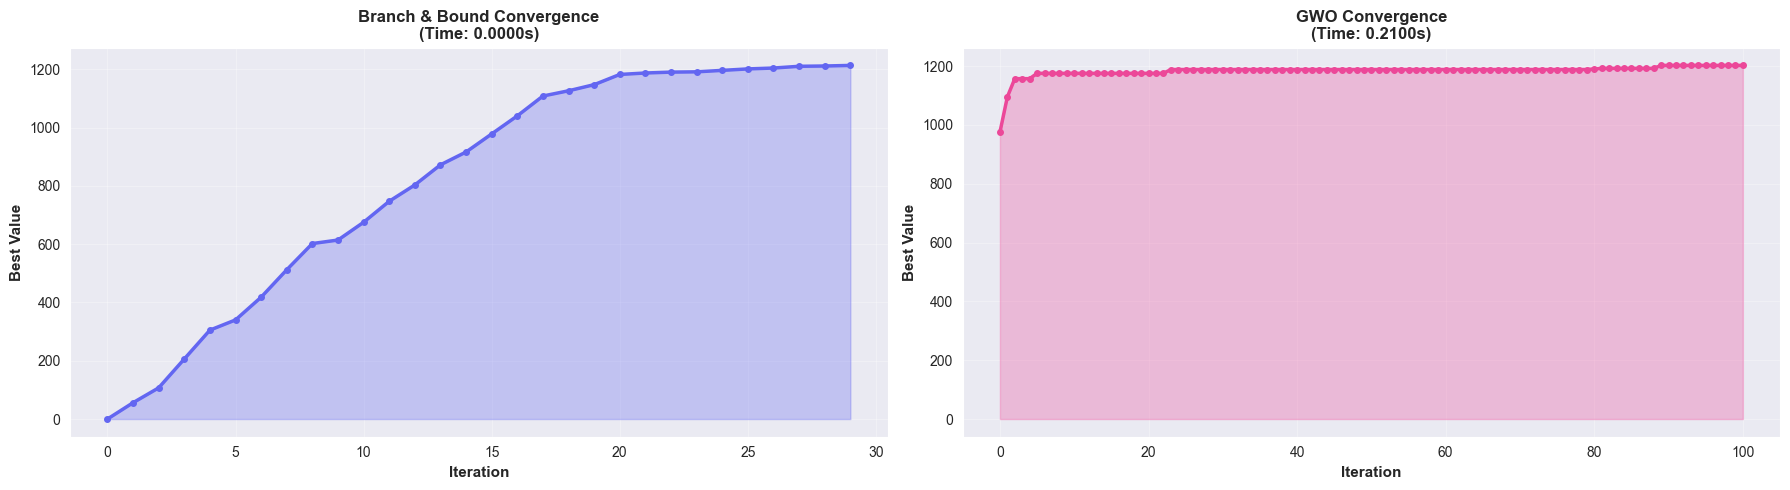

✓ Convergence plots generated


In [11]:
medium_data = df[df['Dataset'] == 'Medium (30 items)'].copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ['#6366f1', '#ec4899', '#10b981']

for idx, (ax, (_, row)) in enumerate(zip(axes, medium_data.iterrows())):
    history = row['History']
    ax.plot(history, linewidth=2.5, color=colors[idx], marker='o', markersize=4)
    ax.fill_between(range(len(history)), history, alpha=0.3, color=colors[idx])
    ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('Best Value', fontsize=11, fontweight='bold')
    ax.set_title(f"{row['Algorithm']} Convergence\n(Time: {row['Time (s)']:.4f}s)", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('✓ Convergence plots generated')

## Part 6: Solution Quality Comparison

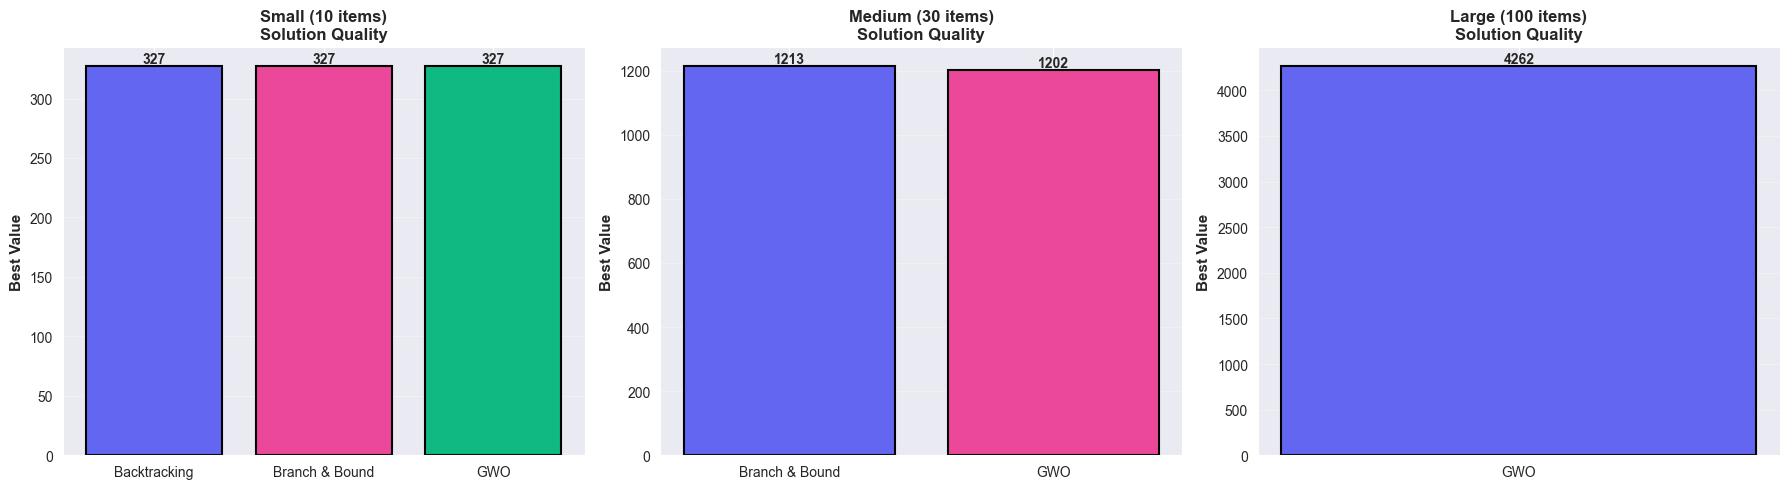

✓ Quality comparison generated


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#6366f1', '#ec4899', '#10b981']

for idx, dataset_name in enumerate(['Small (10 items)', 'Medium (30 items)', 'Large (100 items)']):
    ax = axes[idx]
    subset = df[df['Dataset'] == dataset_name]
    
    bars = ax.bar(subset['Algorithm'], subset['Best Value'], color=colors, edgecolor='black', linewidth=1.5)
    
    for bar, val in zip(bars, subset['Best Value']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.0f}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_ylabel('Best Value', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name}\nSolution Quality', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('✓ Quality comparison generated')

## Part 7: Execution Time Comparison

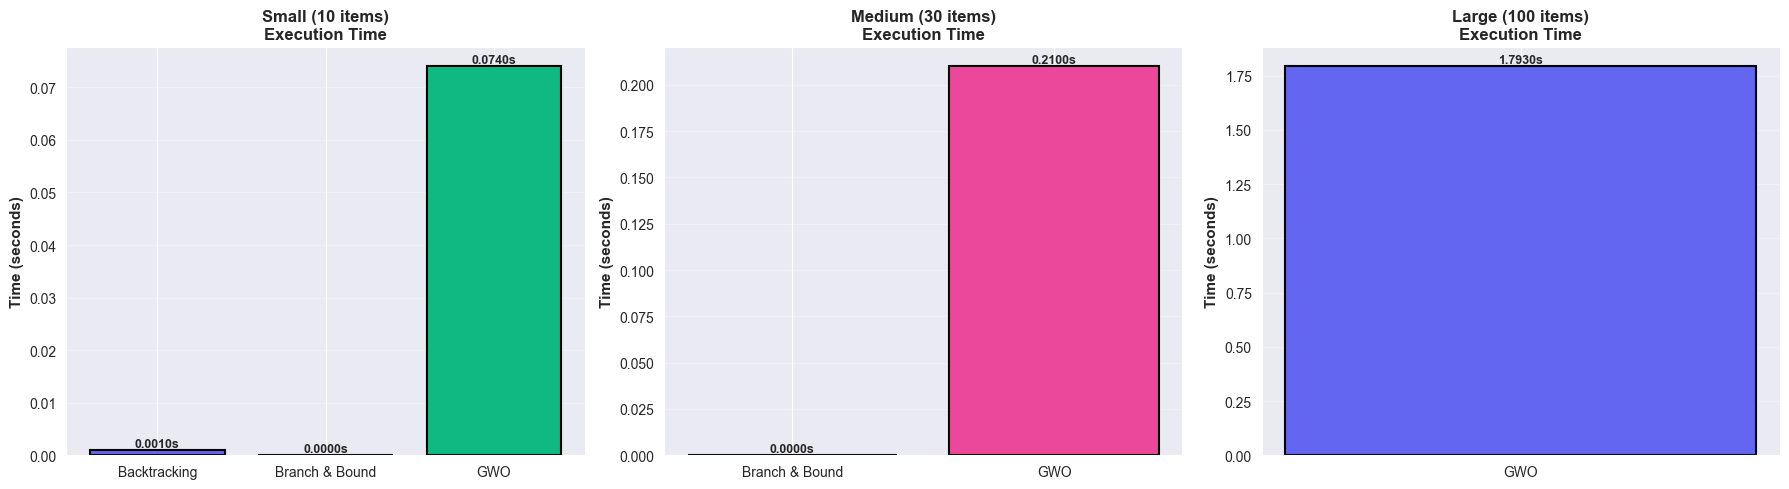

✓ Time comparison generated


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#6366f1', '#ec4899', '#10b981']

for idx, dataset_name in enumerate(['Small (10 items)', 'Medium (30 items)', 'Large (100 items)']):
    ax = axes[idx]
    subset = df[df['Dataset'] == dataset_name]
    
    bars = ax.bar(subset['Algorithm'], subset['Time (s)'], color=colors, edgecolor='black', linewidth=1.5)
    
    for bar, val in zip(bars, subset['Time (s)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.4f}s', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name}\nExecution Time', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('✓ Time comparison generated')

## Part 8: GUI


In [14]:
import tkinter as tk
from tkinter import ttk, messagebox, scrolledtext
import tkinter.font as tkFont
import time

class KnapsackGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("🎒 Advanced Knapsack Solver")
        self.root.geometry("1600x1000")
        self.root.configure(bg="#0f0f23")
        
        # Eye-friendly Light Color Scheme
        self.colors = {
            'bg_primary': "#f8f9fa",
            'bg_secondary': "#ffffff",
            'bg_card': "#e9ecef",
            'bg_input': "#ffffff",
            'accent_primary': "#007bff",
            'accent_secondary': "#dc3545",
            'accent_success': "#28a745",
            'accent_warning': "#ffc107",
            'text_primary': "#212529",
            'text_secondary': "#6c757d",
            'border': "#dee2e6"
        }
        
        self.items = [
            ("Laptop", 3, 2000),
            ("Book", 1, 300),
            ("Phone", 1, 1500),
            ("Water Bottle", 2, 100),
            ("Headphones", 1, 500),
            ("Tablet", 2, 1200),
            ("Camera", 4, 2500),
            ("Charger", 1, 200)
        ]
        self.capacity = 0
        self.results = {}
        self.current_result = None
        self.benchmark_results = []  # Store results from all algorithms
        
        # Configure ttk styles
        self.setup_styles()
        self.setup_ui()
    
    def setup_styles(self):
        style = ttk.Style()
        
        # Button styles
        style.configure("Primary.TButton", 
                       background=self.colors['accent_primary'], 
                       foreground=self.colors['text_primary'],
                       font=("Segoe UI", 10, "bold"),
                       borderwidth=0,
                       relief="flat")
        
        style.configure("Secondary.TButton", 
                       background=self.colors['accent_secondary'], 
                       foreground=self.colors['text_primary'],
                       font=("Segoe UI", 9),
                       borderwidth=0,
                       relief="flat")
        
        style.configure("Success.TButton", 
                       background=self.colors['accent_success'], 
                       foreground=self.colors['text_primary'],
                       font=("Segoe UI", 9, "bold"),
                       borderwidth=0,
                       relief="flat")
        
        # LabelFrame style
        style.configure("Card.TLabelframe", 
                       background=self.colors['bg_card'],
                       foreground=self.colors['text_primary'],
                       borderwidth=2,
                       relief="solid")
        
        style.configure("Card.TLabelframe.Label", 
                       background=self.colors['bg_card'],
                       foreground=self.colors['accent_primary'],
                       font=("Segoe UI", 12, "bold"))
        
        # Notebook style
        style.configure("TNotebook", background=self.colors['bg_primary'], borderwidth=0)
        style.configure("TNotebook.Tab", background=self.colors['bg_secondary'], 
                       foreground=self.colors['text_primary'], font=("Segoe UI", 10, "bold"),
                       padding=[10, 5])
        style.map("TNotebook.Tab", background=[("selected", self.colors['accent_primary'])])
    
    def setup_ui(self):
        # Main container
        main_frame = tk.Frame(self.root, bg=self.colors['bg_primary'])
        main_frame.pack(fill=tk.BOTH, expand=True, padx=20, pady=20)
        
        # Header
        header_frame = tk.Frame(main_frame, bg=self.colors['bg_primary'])
        header_frame.pack(fill=tk.X, pady=(0, 20))
        
        title_font = tkFont.Font(family="Segoe UI", size=24, weight="bold")
        title = tk.Label(header_frame, text="🎒 Advanced Knapsack Solver", 
                        font=title_font, bg=self.colors['bg_primary'], 
                        fg=self.colors['accent_primary'])
        title.pack(side=tk.LEFT)
        
        subtitle = tk.Label(header_frame, text="Optimize your knapsack with multiple algorithms", 
                           font=("Segoe UI", 10), bg=self.colors['bg_primary'], 
                           fg=self.colors['text_secondary'])
        subtitle.pack(side=tk.LEFT, padx=(20, 0))
        
        # Content frame for grid layout
        content_frame = tk.Frame(main_frame, bg=self.colors['bg_primary'])
        content_frame.pack(fill=tk.BOTH, expand=True, pady=(0, 20))
        
        # Main content - Solver interface
        self.setup_solver_tab(content_frame)
        
        # Load sample data into listbox
        for item in self.items:
            self.items_listbox.insert(tk.END, f"🏷️ {item[0]:12s} | ⚖️ {item[1]:3d} | 💎 {item[2]:3d} | 📊 {item[2]/item[1]:.2f}")
        
        # Status bar
        self.status_var = tk.StringVar(value=f"✓ Loaded {len(self.items)} sample items. Ready to optimize!")
        status_bar = tk.Label(main_frame, textvariable=self.status_var, 
                             bg=self.colors['bg_secondary'], fg=self.colors['accent_success'], 
                             font=("Segoe UI", 9, "bold"), relief="sunken", bd=1)
        status_bar.pack(fill=tk.X)
    
    def setup_solver_tab(self, parent):
        parent.columnconfigure(0, weight=1)
        parent.columnconfigure(1, weight=1)
        parent.columnconfigure(2, weight=1)
        
        # Left panel - Item Management
        left_card = ttk.LabelFrame(parent, text="📦 Item Management", style="Card.TLabelframe")
        left_card.grid(row=0, column=0, sticky="nsew", padx=5, pady=5)
        self.setup_item_management(left_card)
        
        # Middle panel - Algorithm Selection & Parameters
        middle_card = ttk.LabelFrame(parent, text="⚙️ Algorithm Configuration", style="Card.TLabelframe")
        middle_card.grid(row=0, column=1, sticky="nsew", padx=5, pady=5)
        self.setup_algorithm_panel(middle_card)
        
        # Right panel - Results
        right_card = ttk.LabelFrame(parent, text="📊 Results & Analysis", style="Card.TLabelframe")
        right_card.grid(row=0, column=2, sticky="nsew", padx=5, pady=5)
        self.setup_results_panel(right_card)
    
    def setup_item_management(self, parent):
        # Input fields with better styling
        input_frame = tk.Frame(parent, bg=self.colors['bg_card'])
        input_frame.pack(fill=tk.X, pady=10, padx=10)
        
        # Name input
        name_frame = tk.Frame(input_frame, bg=self.colors['bg_card'])
        name_frame.pack(fill=tk.X, pady=5)
        tk.Label(name_frame, text="🏷️ Name:", bg=self.colors['bg_card'], 
                fg=self.colors['text_primary'], font=("Segoe UI", 10, "bold")).pack(anchor=tk.W)
        self.name_entry = tk.Entry(name_frame, bg=self.colors['bg_input'], 
                                  fg=self.colors['text_primary'],
                                  insertbackground=self.colors['text_primary'], 
                                  font=("Segoe UI", 10), relief="flat", bd=2)
        self.name_entry.pack(fill=tk.X, pady=2)
        
        # Weight input
        weight_frame = tk.Frame(input_frame, bg=self.colors['bg_card'])
        weight_frame.pack(fill=tk.X, pady=5)
        tk.Label(weight_frame, text="⚖️ Weight:", bg=self.colors['bg_card'], 
                fg=self.colors['text_primary'], font=("Segoe UI", 10, "bold")).pack(anchor=tk.W)
        self.weight_entry = tk.Entry(weight_frame, bg=self.colors['bg_input'], 
                                    fg=self.colors['text_primary'],
                                    insertbackground=self.colors['text_primary'], 
                                    font=("Segoe UI", 10), relief="flat", bd=2)
        self.weight_entry.pack(fill=tk.X, pady=2)
        
        # Value input
        value_frame = tk.Frame(input_frame, bg=self.colors['bg_card'])
        value_frame.pack(fill=tk.X, pady=5)
        tk.Label(value_frame, text="💎 Value:", bg=self.colors['bg_card'], 
                fg=self.colors['text_primary'], font=("Segoe UI", 10, "bold")).pack(anchor=tk.W)
        self.value_entry = tk.Entry(value_frame, bg=self.colors['bg_input'], 
                                   fg=self.colors['text_primary'],
                                   insertbackground=self.colors['text_primary'], 
                                   font=("Segoe UI", 10), relief="flat", bd=2)
        self.value_entry.pack(fill=tk.X, pady=2)
        
        # Buttons
        btn_frame = tk.Frame(input_frame, bg=self.colors['bg_card'])
        btn_frame.pack(fill=tk.X, pady=10)
        btn_frame.columnconfigure(0, weight=1)
        btn_frame.columnconfigure(1, weight=1)
        
        add_btn = tk.Button(btn_frame, text="➕ Add Item", command=self.add_item,
                           bg=self.colors['accent_primary'], fg=self.colors['text_primary'], 
                           font=("Segoe UI", 10, "bold"), relief="flat", bd=0, 
                           activebackground=self.colors['accent_secondary'], cursor="hand2")
        add_btn.grid(row=0, column=0, sticky="ew", padx=(0, 5))
        
        clear_btn = tk.Button(btn_frame, text="🔄 Clear All", command=self.clear_items,
                             bg=self.colors['accent_warning'], fg=self.colors['bg_primary'], 
                             font=("Segoe UI", 9, "bold"), relief="flat", bd=0, 
                             activebackground=self.colors['accent_secondary'], cursor="hand2")
        clear_btn.grid(row=0, column=1, sticky="ew", padx=(5, 0))
        
        # Capacity input
        cap_frame = tk.Frame(input_frame, bg=self.colors['bg_card'])
        cap_frame.pack(fill=tk.X, pady=10)
        tk.Label(cap_frame, text="🎒 Knapsack Capacity:", bg=self.colors['bg_card'], 
                fg=self.colors['text_primary'], font=("Segoe UI", 10, "bold")).pack(anchor=tk.W)
        self.capacity_entry = tk.Entry(cap_frame, bg=self.colors['bg_input'], 
                                      fg=self.colors['text_primary'],
                                      insertbackground=self.colors['text_primary'], 
                                      font=("Segoe UI", 10), relief="flat", bd=2)
        self.capacity_entry.pack(fill=tk.X, pady=2)
        self.capacity_entry.insert(0, "10")
        
        # Items list with scrollbar
        list_frame = tk.Frame(parent, bg=self.colors['bg_card'])
        list_frame.pack(fill=tk.BOTH, expand=True, pady=10, padx=10)
        
        tk.Label(list_frame, text="📋 Current Items:", bg=self.colors['bg_card'], 
                fg=self.colors['text_primary'], font=("Segoe UI", 10, "bold")).pack(anchor=tk.W)
        
        # Scrollable listbox
        scrollbar = tk.Scrollbar(list_frame)
        scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
        
        self.items_listbox = tk.Listbox(list_frame, bg=self.colors['bg_input'], 
                                       fg=self.colors['text_primary'], height=12,
                                       selectmode=tk.SINGLE, font=("Consolas", 9),
                                       yscrollcommand=scrollbar.set, relief="flat", bd=2)
        self.items_listbox.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        scrollbar.config(command=self.items_listbox.yview)
        
        # Delete button
        del_btn = tk.Button(list_frame, text="🗑️ Delete Selected", command=self.delete_item,
                           bg=self.colors['accent_secondary'], fg=self.colors['text_primary'], 
                           font=("Segoe UI", 9, "bold"), relief="flat", bd=0, 
                           activebackground=self.colors['accent_primary'], cursor="hand2")
        del_btn.pack(fill=tk.X, pady=5)
    
    def setup_algorithm_panel(self, parent):
        # Algorithm selection
        algo_frame = tk.Frame(parent, bg=self.colors['bg_card'])
        algo_frame.pack(fill=tk.X, pady=10, padx=10)
        
        tk.Label(algo_frame, text="🤖 Select Algorithm:", bg=self.colors['bg_card'], 
                fg=self.colors['text_primary'], font=("Segoe UI", 10, "bold")).pack(anchor=tk.W, pady=(0, 5))
        
        self.algorithm_var = tk.StringVar(value="Branch & Bound")
        algo_combo = ttk.Combobox(algo_frame, textvariable=self.algorithm_var,
                                 values=["Backtracking", "Branch & Bound", "Grey Wolf Optimizer"],
                                 state="readonly", font=("Segoe UI", 10))
        algo_combo.pack(fill=tk.X)
        
        # GWO Parameters
        gwo_frame = tk.Frame(parent, bg=self.colors['bg_card'])
        gwo_frame.pack(fill=tk.X, pady=10, padx=10)
        
        tk.Label(gwo_frame, text="🐺 GWO Parameters:", bg=self.colors['bg_card'], 
                fg=self.colors['text_primary'], font=("Segoe UI", 10, "bold")).pack(anchor=tk.W, pady=(0, 5))
        
        # Population
        pop_frame = tk.Frame(gwo_frame, bg=self.colors['bg_card'])
        pop_frame.pack(fill=tk.X, pady=2)
        tk.Label(pop_frame, text="Population:", bg=self.colors['bg_card'], 
                fg=self.colors['text_secondary'], font=("Segoe UI", 9)).pack(side=tk.LEFT)
        self.pop_entry = tk.Entry(pop_frame, bg=self.colors['bg_input'], 
                                 fg=self.colors['text_primary'], width=10,
                                 insertbackground=self.colors['text_primary'], 
                                 font=("Segoe UI", 9), relief="flat", bd=2)
        self.pop_entry.pack(side=tk.RIGHT)
        self.pop_entry.insert(0, "30")
        
        # Iterations
        iter_frame = tk.Frame(gwo_frame, bg=self.colors['bg_card'])
        iter_frame.pack(fill=tk.X, pady=2)
        tk.Label(iter_frame, text="Iterations:", bg=self.colors['bg_card'], 
                fg=self.colors['text_secondary'], font=("Segoe UI", 9)).pack(side=tk.LEFT)
        self.iter_entry = tk.Entry(iter_frame, bg=self.colors['bg_input'], 
                                  fg=self.colors['text_primary'], width=10,
                                  insertbackground=self.colors['text_primary'], 
                                  font=("Segoe UI", 9), relief="flat", bd=2)
        self.iter_entry.pack(side=tk.RIGHT)
        self.iter_entry.insert(0, "100")
        
        # Solve button
        solve_btn = tk.Button(parent, text="🚀 SOLVE KNAPSACK", command=self.solve_knapsack,
                             bg=self.colors['accent_success'], fg=self.colors['text_primary'], 
                             font=("Segoe UI", 12, "bold"), relief="flat", bd=0, 
                             activebackground=self.colors['accent_primary'], cursor="hand2", height=2)
        solve_btn.pack(fill=tk.X, padx=10, pady=20)
        
        # Benchmark button
        benchmark_btn = tk.Button(parent, text="📊 RUN BENCHMARK", command=self.run_benchmark,
                                 bg=self.colors['accent_warning'], fg=self.colors['bg_primary'], 
                                 font=("Segoe UI", 10, "bold"), relief="flat", bd=0, 
                                 activebackground=self.colors['accent_primary'], cursor="hand2", height=1)
        benchmark_btn.pack(fill=tk.X, padx=10, pady=5)
    
    def setup_results_panel(self, parent):
        # Results text area
        self.results_text = scrolledtext.ScrolledText(parent, wrap=tk.WORD, 
                                                     bg=self.colors['bg_input'], 
                                                     fg=self.colors['text_primary'],
                                                     font=("Consolas", 9), relief="flat", bd=2,
                                                     insertbackground=self.colors['text_primary'])
        self.results_text.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        self.results_text.insert(tk.END, "Results will appear here after solving...\n\n")
        self.results_text.config(state=tk.DISABLED)
    
    def add_item(self):
        try:
            name = self.name_entry.get().strip()
            if not name:
                name = f"Item {len(self.items) + 1}"
            
            weight = int(self.weight_entry.get())
            value = int(self.value_entry.get())
            
            if weight <= 0 or value <= 0:
                messagebox.showerror("Error", "Weight and Value must be positive!", 
                                   icon="warning", parent=self.root)
                return
            
            self.items.append((name, weight, value))
            self.items_listbox.insert(tk.END, f"🏷️ {name:12s} | ⚖️ {weight:3d} | 💎 {value:3d} | 📊 {value/weight:.2f}")
            
            self.name_entry.delete(0, tk.END)
            self.weight_entry.delete(0, tk.END)
            self.value_entry.delete(0, tk.END)
            self.name_entry.focus()
            
            self.status_var.set(f"✓ Item added. Total items: {len(self.items)}")
        except ValueError:
            messagebox.showerror("Error", "Please enter valid numbers!", 
                               icon="error", parent=self.root)
    
    def delete_item(self):
        try:
            index = self.items_listbox.curselection()[0]
            self.items.pop(index)
            self.items_listbox.delete(index)
            self.status_var.set(f"✓ Item deleted. Total items: {len(self.items)}")
        except IndexError:
            messagebox.showwarning("Warning", "Please select an item to delete!", 
                                 icon="info", parent=self.root)
    
    def clear_items(self):
        if messagebox.askyesno("Confirm", "Clear all items and capacity?", 
                              icon="question", parent=self.root):
            self.items.clear()
            self.items_listbox.delete(0, tk.END)
            self.name_entry.delete(0, tk.END)
            self.capacity_entry.delete(0, tk.END)
            self.status_var.set("✓ All items cleared")
    
    def solve_knapsack(self):
        if not self.items:
            messagebox.showerror("Error", "Please add some items first!", 
                               icon="error", parent=self.root)
            return
        
        try:
            capacity = int(self.capacity_entry.get())
            if capacity <= 0:
                raise ValueError
        except ValueError:
            messagebox.showerror("Error", "Please enter a valid capacity!", 
                               icon="error", parent=self.root)
            return
        
        algorithm = self.algorithm_var.get()
        self.status_var.set(f"🔄 Solving with {algorithm}...")
        self.root.update()
        
        start_time = time.time()
        
        try:
            # Extract weight, value for solvers
            solver_items = [(w, v) for _, w, v in self.items]
            
            if algorithm == "Backtracking":
                solver = BacktrackingSolver(capacity, solver_items)
            elif algorithm == "Branch & Bound":
                solver = BranchAndBoundSolver(capacity, solver_items)
            else:  # Grey Wolf Optimizer
                pop = int(self.pop_entry.get())
                iters = int(self.iter_entry.get())
                solver = GWOSolver(capacity, solver_items, pop, iters)
            
            result = solver.solve()
            self.current_result = result
            self.current_algorithm = algorithm
            
            # Display results
            self.results_text.config(state=tk.NORMAL)
            self.results_text.delete(1.0, tk.END)
            
            self.results_text.insert(tk.END, f"🎯 SOLUTION RESULTS\n")
            self.results_text.insert(tk.END, "="*50 + "\n\n")
            self.results_text.insert(tk.END, f"Algorithm: {algorithm}\n")
            self.results_text.insert(tk.END, f"Items: {len(self.items)}\n")
            self.results_text.insert(tk.END, f"Capacity: {capacity}\n")
            self.results_text.insert(tk.END, f"Execution Time: {result['execution_time']:.4f} seconds\n\n")
            
            self.results_text.insert(tk.END, f"💰 MAXIMUM VALUE: {result['best_value']}\n\n")
            
            # Selected items
            self.results_text.insert(tk.END, "📦 SELECTED ITEMS:\n")
            total_weight = 0
            for i, selected in enumerate(result['best_solution']):
                if selected == 1:
                    name, weight, value = self.items[i]
                    total_weight += weight
                    self.results_text.insert(tk.END, f"  • {name}: Weight={weight}, Value={value}\n")
            
            self.results_text.insert(tk.END, f"\n⚖️ TOTAL WEIGHT: {total_weight}/{capacity}\n")
            
            if 'nodes_pruned' in result:
                self.results_text.insert(tk.END, f"✂️ NODES PRUNED: {result['nodes_pruned']}\n")
            
            self.results_text.config(state=tk.DISABLED)
            
            solve_time = time.time() - start_time
            self.status_var.set(f"✅ Solved! Value: {result['best_value']} | Time: {solve_time:.4f}s")
            
        except Exception as e:
            messagebox.showerror("Error", f"Solving failed: {str(e)}", 
                               icon="error", parent=self.root)
            self.status_var.set("❌ Solving failed")
    
    def run_benchmark(self):
        if not self.items:
            messagebox.showerror("Error", "Please add some items first!", 
                               icon="error", parent=self.root)
            return
        
        try:
            capacity = int(self.capacity_entry.get())
            if capacity <= 0:
                raise ValueError
        except ValueError:
            messagebox.showerror("Error", "Please enter a valid capacity!", 
                               icon="error", parent=self.root)
            return
        
        self.status_var.set("🔄 Running benchmark with all algorithms...")
        self.root.update()
        
        solver_items = [(w, v) for _, w, v in self.items]
        algorithms = [
            ("Backtracking", BacktrackingSolver(capacity, solver_items)),
            ("Branch & Bound", BranchAndBoundSolver(capacity, solver_items)),
            ("Grey Wolf Optimizer", GWOSolver(capacity, solver_items, int(self.pop_entry.get()), int(self.iter_entry.get())))
        ]
        
        self.benchmark_results = []
        for algo_name, solver in algorithms:
            self.status_var.set(f"🔄 Running {algo_name}...")
            self.root.update()
            result = solver.solve()
            self.benchmark_results.append({
                'Algorithm': algo_name,
                'Best Value': result['best_value'],
                'Time (s)': result['execution_time'],
                'History': result['convergence_history']
            })
        
        # Display benchmark results
        self.results_text.config(state=tk.NORMAL)
        self.results_text.delete(1.0, tk.END)
        
        self.results_text.insert(tk.END, f"📊 BENCHMARK RESULTS\n")
        self.results_text.insert(tk.END, "="*50 + "\n\n")
        self.results_text.insert(tk.END, f"Dataset: {len(self.items)} items, Capacity: {capacity}\n\n")
        
        for result in self.benchmark_results:
            self.results_text.insert(tk.END, f"🤖 {result['Algorithm']}\n")
            self.results_text.insert(tk.END, f"  💰 Best Value: {result['Best Value']}\n")
            self.results_text.insert(tk.END, f"  ⏱️ Time: {result['Time (s)']:.4f}s\n\n")
        
        self.results_text.config(state=tk.DISABLED)
        
        self.status_var.set("✅ Benchmark complete!")

def main():
    root = tk.Tk()
    app = KnapsackGUI(root)
    root.mainloop()

if __name__ == "__main__":
    main()
